# Notebook 3: rankings and measures

> **Version 2 (recomputed after the deck-selection analysis).** The first version of this notebook used the decks from the game engine's `DECK_TABLE`. Notebook 4 showed that under our own criteria (the brief, literally) the optimal deck is different - usually smaller - for 8 of the 12 player counts. This notebook is recomputed on the decks chosen in notebook 4 (`tayan_lab.game_phases.choose_deck`), not the engine's deck.

**This notebook's question (research question 1 from the brief):** is the current hand ordering correct? If not, what ordering is correct, for each deck and player count?

Here we combine notebook 1 (hand odds p_c) with notebook 2 (the N distribution in a typical game), to get a single "how good is this ranking" number for the whole game, not just for one N.

**Three rankings:**

| Ranking | When it's computed | Role |
|---|---|---|
| **current** | never - it's simply today's in-game ordering | baseline |
| **static** | once, at game start | **candidate for the new default ordering** |
| **dynamic** | every round, separately for each N | **reference point only** |

**epsilon (the tie-break threshold) = 2 pp.**

In [1]:
from fractions import Fraction

import matplotlib.pyplot as plt
import pandas as pd

from tayan_lab.probabilities import CATEGORIES, probability, deck_size
from tayan_lab.game_phases import choose_deck
from tayan_lab.pool_size_distribution import pool_size_distribution
from tayan_lab.rankings import (
    CURRENT_ORDER, dynamic_ranking, expected_ranking_changes, inversion_mass,
    kendall_tau, rank_categories, staged_ranking, static_ranking, weighted_inversion_mass, weighted_probabilities,
)

LABELS = {
    "HIGH": "high card", "PAIR": "pair", "TWO_PAIR": "two pair", "STRAIGHT": "straight",
    "THREE": "three of a kind", "FLUSH": "flush", "FULL": "full house", "FOUR": "four of a kind", "STRAIGHT_FLUSH": "straight flush",
}
COLORS = {
    "HIGH": "#8a8983", "PAIR": "#2a78d6", "TWO_PAIR": "#eb6834", "STRAIGHT": "#1baf7a",
    "THREE": "#eda100", "FLUSH": "#e87ba4", "FULL": "#008300", "FOUR": "#4a3aa7", "STRAIGHT_FLUSH": "#e34948",
}
INK, INK2, GRID = "#0b0b0b", "#52514e", "#e6e5e1"
plt.rcParams.update({
    "figure.facecolor": "white", "axes.facecolor": "white", "axes.edgecolor": GRID,
    "axes.labelcolor": INK2, "xtick.color": INK2, "ytick.color": INK2, "text.color": INK,
    "axes.spines.top": False, "axes.spines.right": False, "font.size": 10,
})
EPSILON = 2.0

def label_ranking(r):
    return " -> ".join(LABELS[c] for c in r)

def default_start(players):
    return 2 if players <= 7 else 1  # raised from <=6, see notebook 4's starting-cards section

def default_limit(players):
    return 6 if players <= 10 else 5

# Deck chosen in notebook 4 (not the engine's deck!) -- computed live here so it never drifts out of sync.
DECK_TABLE = {p: choose_deck(p, default_start(p), default_limit(p)).lowest_rank for p in range(2, 14)}
DECK_TABLE

{2: 9, 3: 9, 4: 9, 5: 8, 6: 7, 7: 6, 8: 5, 9: 3, 10: 2, 11: 4, 12: 3, 13: 2}

## 1. How we compute a ranking: a step-by-step example

**Static ranking:** for each category, compute the average p weighted by the w(N) distribution from notebook 2, then sort categories from most to least frequent. Close values (difference <= epsilon) stay in the baseline order.

Example: 2 players. The 2-player deck hasn't changed relative to the engine's (L=9 in both cases), so this is also a good chance to compare the method 1:1 with the first version of this notebook.

In [2]:
players, L = 2, DECK_TABLE[2]
p = weighted_probabilities(L, players, default_start(players), default_limit(players))
df = pd.DataFrame({"category": [LABELS[c] for c in CATEGORIES], "avg. p (%)": [float(p[c]) * 100 for c in CATEGORIES]})
df = df.sort_values("avg. p (%)", ascending=False).reset_index(drop=True)
df.style.format({"avg. p (%)": "{:.2f}"}).hide(axis="index")

category,avg. p (%)
high card,72.61
pair,29.41
straight,17.68
two pair,7.90
three of a kind,5.80
full house,1.43
flush,0.47
four of a kind,0.42
straight flush,0.09


In [3]:
ranking, _ = static_ranking(L, players, default_start(players), default_limit(players), epsilon_pp=EPSILON)
print("Static ranking (weakest to strongest):")
print(label_ranking(ranking))
print()
print("For comparison, the current order:")
print(label_ranking(CURRENT_ORDER))

Static ranking (weakest to strongest):
high card -> pair -> straight -> two pair -> three of a kind -> flush -> full house -> four of a kind -> straight flush

For comparison, the current order:
high card -> pair -> two pair -> straight -> three of a kind -> flush -> full house -> four of a kind -> straight flush


## 2. Inversion mass: how much the current ordering loses, how much the static one does

Inversion mass sums `(p_higher - p_lower)` over every pair of categories where the category ranked higher is actually more frequent (by more than epsilon), **weighted by the whole game's w(N) distribution**.

**Criterion:** the static ranking is good enough if it leaves <= 10% of the current ordering's inversion mass.

In [4]:
rows = []
for players in range(2, 14):
    L = DECK_TABLE[players]
    start, limit = default_start(players), default_limit(players)
    ranking, _ = static_ranking(L, players, start, limit, epsilon_pp=EPSILON)
    m_current = weighted_inversion_mass(CURRENT_ORDER, L, players, start, limit, epsilon_pp=EPSILON)
    m_static = weighted_inversion_mass(ranking, L, players, start, limit, epsilon_pp=EPSILON)
    ratio = float(m_static / m_current) * 100 if m_current > 0 else 0.0
    rows.append({
        "players": players, "deck (L)": L, "m current (pp)": float(m_current) * 100,
        "m static (pp)": float(m_static) * 100, "static / current": ratio,
        "good enough (<=10%)": ratio <= 10.0, "ranking differs": ranking != CURRENT_ORDER,
        "_ranking": ranking,
    })
df_mass = pd.DataFrame(rows)
df_mass.drop(columns="_ranking").style.format({
    "m current (pp)": "{:.2f}", "m static (pp)": "{:.2f}", "static / current": "{:.2f}%",
}).hide(axis="index")

players,deck (L),m current (pp),m static (pp),static / current,good enough (<=10%),ranking differs
2,9,10.24,0.57,5.58%,True,True
3,9,25.28,1.50,5.93%,True,True
4,9,35.99,3.60,9.99%,True,True
5,8,26.53,3.82,14.40%,False,True
6,7,31.87,2.59,8.12%,True,True
7,6,46.55,2.21,4.74%,True,True
8,5,54.60,3.49,6.39%,True,True
9,3,91.35,5.85,6.40%,True,True
10,2,114.60,4.12,3.60%,True,True
11,4,75.96,6.84,9.00%,True,True


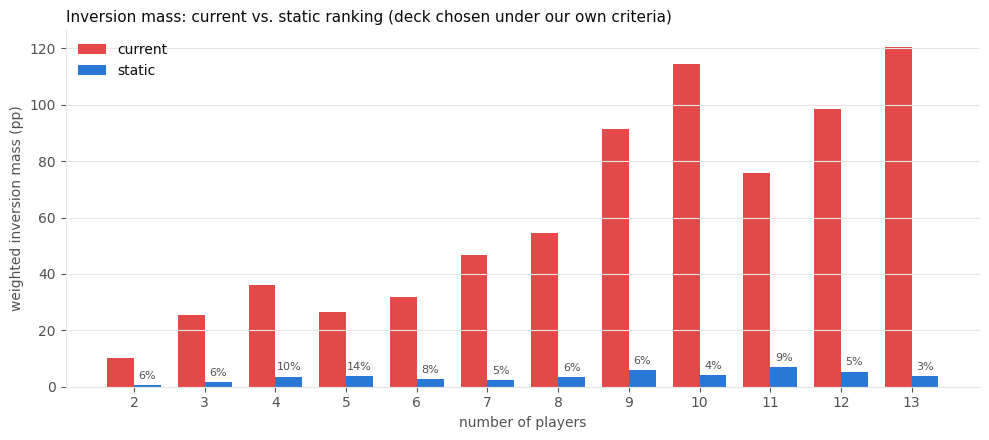

In [5]:
fig, ax = plt.subplots(figsize=(10, 4.5))
x = df_mass["players"]
w = 0.38
ax.bar(x - w/2, df_mass["m current (pp)"], width=w, color="#e34948", label="current")
bars_static = ax.bar(x + w/2, df_mass["m static (pp)"], width=w, color="#2a78d6", label="static")
for bar, ratio in zip(bars_static, df_mass["static / current"]):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1.5, f"{ratio:.0f}%",
            ha="center", va="bottom", fontsize=8, color=INK2)
ax.set_xlabel("number of players")
ax.set_ylabel("weighted inversion mass (pp)")
ax.set_title("Inversion mass: current vs. static ranking (deck chosen under our own criteria)",
              loc="left", color=INK, fontsize=11)
ax.set_xticks(list(x))
ax.grid(axis="y", color=GRID, lw=0.8)
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

**Conclusion:** for most player counts the static ranking stays safely below the 10% threshold. But **not for all**:

- **4 players: a borderline case** (9.99% out of 10%) - technically passes, with no margin.
- **5 players: 14.40% - does NOT pass.**
- 7 players: 4.74% - passes comfortably. (This number already includes a fix applied later in notebook 4 - 2 starting cards instead of 1 - once the same problem showed up even more clearly there. We've applied the fix here retroactively so this notebook stays consistent with the final recommendation in this repo's README. Without the fix, 7 players wouldn't pass either, at 13.28%.)

If static isn't enough, the natural next step is to **consider dynamic for that player count**. For 5 players that doesn't automatically mean "deploy dynamic" - section 5d shows that a **staged** ranking gives 5 players a 73% error reduction for the cost of just 1 switch per game, which may be a better trade-off than full dynamic. We come back to this in section 7.

## 3. What the correct ordering is

Table of the recommended ordering for each player count, on the decks chosen in notebook 4.

In [6]:
rows = []
for players in range(2, 14):
    r = df_mass.loc[df_mass["players"] == players, "_ranking"].iloc[0]
    rows.append({"players": players, "deck (L)": DECK_TABLE[players], "recommended order": label_ranking(r)})
pd.DataFrame(rows).style.hide(axis="index")

players,deck (L),recommended order
2,9,high card -> pair -> straight -> two pair -> three of a kind -> flush -> full house -> four of a kind -> straight flush
3,9,high card -> pair -> straight -> two pair -> three of a kind -> full house -> flush -> four of a kind -> straight flush
4,9,high card -> pair -> straight -> two pair -> three of a kind -> full house -> flush -> four of a kind -> straight flush
5,8,high card -> pair -> straight -> two pair -> three of a kind -> flush -> full house -> four of a kind -> straight flush
6,7,high card -> straight -> pair -> two pair -> flush -> three of a kind -> full house -> four of a kind -> straight flush
7,6,high card -> straight -> pair -> flush -> two pair -> three of a kind -> full house -> four of a kind -> straight flush
8,5,high card -> pair -> straight -> flush -> two pair -> three of a kind -> full house -> four of a kind -> straight flush
9,3,high card -> flush -> pair -> straight -> two pair -> three of a kind -> full house -> four of a kind -> straight flush
10,2,high card -> flush -> pair -> straight -> two pair -> three of a kind -> full house -> four of a kind -> straight flush
11,4,high card -> pair -> straight -> flush -> two pair -> three of a kind -> full house -> four of a kind -> straight flush


**What changes relative to today's ordering (high card, pair, two pair, straight, three of a kind, flush, full house, four of a kind, straight flush):**

- **Pair and straight are close to each other** for 4-7 players - which comes first depends on epsilon (see section 4, this is unstable in this range).
- **Flush overtakes pair** for 9-13 players.
- For 8 players the order is pair -> straight -> flush (unchanged from today within this trio, other than two pair and three of a kind dropping lower).

This is a different picture than in the first version of this notebook (where the problem mainly concerned 6-7 players and the flush/pair pair) - on the corrected decks, the uncertainty shifts to **pair/straight** and covers **4-7 players**, a larger part of the priority group (2-6 players is the expected common game size, so this group gets the closest attention throughout).

## 4. Sensitivity analysis: are the conclusions stable

Static ranking for epsilon in {1, 2, 3} pp.

In [7]:
rows = []
for players in range(2, 14):
    L = DECK_TABLE[players]
    start, limit = default_start(players), default_limit(players)
    variants = {eps: static_ranking(L, players, start, limit, epsilon_pp=eps)[0] for eps in (1.0, 2.0, 3.0)}
    stable = len(set(variants.values())) == 1
    rows.append({
        "players": players, "stable for eps=1/2/3": "yes" if stable else "NO",
        "ranking (eps=1)": label_ranking(variants[1.0]) if not stable else "",
    })
df_sens = pd.DataFrame(rows)
df_sens.style.hide(axis="index")

players,stable for eps=1/2/3,ranking (eps=1)
2,yes,
3,yes,
4,NO,high card -> straight -> pair -> two pair -> three of a kind -> full house -> flush -> four of a kind -> straight flush
5,NO,high card -> straight -> pair -> two pair -> three of a kind -> flush -> full house -> four of a kind -> straight flush
6,NO,high card -> straight -> pair -> two pair -> flush -> three of a kind -> full house -> four of a kind -> straight flush
7,NO,high card -> straight -> pair -> flush -> two pair -> three of a kind -> full house -> four of a kind -> straight flush
8,yes,
9,yes,
10,yes,
11,yes,


**Conclusion:** the recommendation is stable for 2, 3, 8, 9, 10, 11, 12, 13 players. **For 4, 5, 6 and 7 players the pair/straight order depends on epsilon** - the difference p(pair)-p(straight) is on the order of +-1.3 to +-2 pp there, i.e. within the noise of our tie-break threshold. **We do not recommend** swapping pair and straight for 4-7 players - they stay in today's order (pair before straight), per the tie-break rule.

This is a different, and frankly less convenient, result than before the deck was recomputed in notebook 4: the uncertainty didn't go away, it just moved to a different pair of categories and now covers more player counts from the priority group. But it is **methodologically consistent** - it comes from the same mechanism (close whole-game averages), not from an error.

## 5. Dynamic ranking: what it gains and what it costs

Dynamic doesn't become a lobby mode - here's why.

In [8]:
rows = []
for players in range(2, 14):
    L = DECK_TABLE[players]
    start, limit = default_start(players), default_limit(players)
    ranking, _ = static_ranking(L, players, start, limit, epsilon_pp=EPSILON)
    tau = kendall_tau(CURRENT_ORDER, ranking)
    changes = expected_ranking_changes(L, players, start, limit, epsilon_pp=EPSILON, hysteresis=True)
    rows.append({
        "players": players, "Kendall's tau (current vs. static)": float(tau),
        "ranking changes / game (dynamic, with hysteresis)": float(changes),
    })
df_dyn = pd.DataFrame(rows)
df_dyn.style.format({"Kendall's tau (current vs. static)": "{:.2f}", "ranking changes / game (dynamic, with hysteresis)": "{:.1f}"}).hide(axis="index")

players,Kendall's tau (current vs. static),"ranking changes / game (dynamic, with hysteresis)"
2,0.94,1.6
3,0.89,2.6
4,0.89,3.3
5,0.94,3.4
6,0.83,4.0
7,0.78,3.6
8,0.83,7.1
9,0.72,7.3
10,0.72,6.1
11,0.83,6.1


**How to read this:** tau = 1 means identical orderings. Values of 0.7-1.0 show moderate differences. The cost of dynamic (2-8 changes per game) is still real, regardless of deck.

## 5b. Static vs. dynamic: exactly where the difference lies

The dynamic ranking by definition always has zero inversion mass (it sorts by the exact current-round odds). The question: **in which phase of the game does static fall behind it?**

Example: 9 players, the deck chosen in notebook 4 (not the engine's deck as in the first version of this notebook).

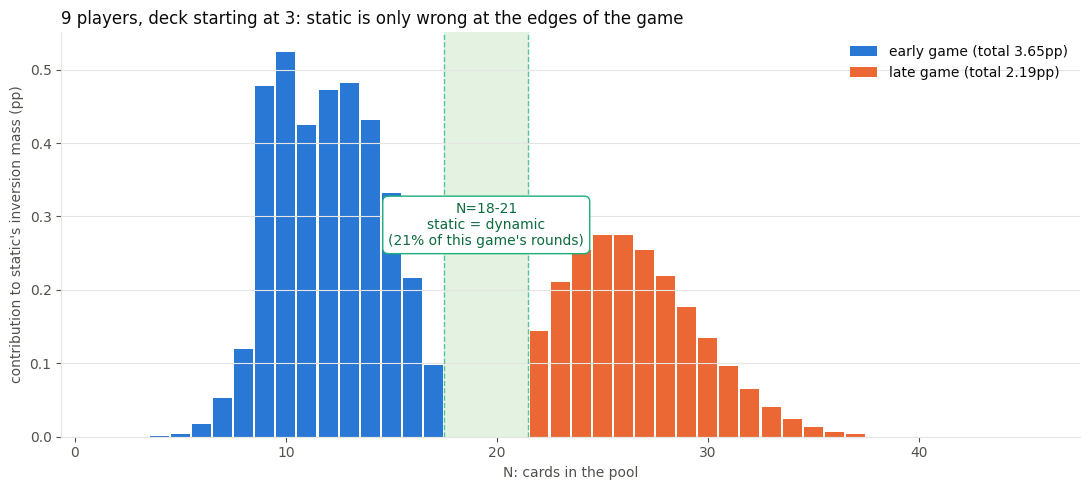

Sum of contributions = 5.85 pp (same number as 'm static' for 9 players in section 2)


In [9]:
def contribution_by_n(ranking, lowest_rank, players, starting_cards, elimination_limit, epsilon_pp=EPSILON):
    dist = pool_size_distribution(players, starting_cards, elimination_limit)
    rows = []
    for n in sorted(dist.by_pool_size):
        w = float(dist.by_pool_size[n] / dist.expected_rounds)
        p = {c: probability(c, lowest_rank, n) for c in CATEGORIES}
        raw_mass = float(inversion_mass(ranking, p, epsilon_pp)) * 100
        rows.append({"N": n, "w(N)%": w * 100, "local mass (pp)": raw_mass, "contribution to result (pp)": w * raw_mass})
    return pd.DataFrame(rows)

players_example = 9
L_example = DECK_TABLE[players_example]
ranking_example, _ = static_ranking(L_example, players_example, default_start(players_example), default_limit(players_example), epsilon_pp=EPSILON)
df_contrib = contribution_by_n(ranking_example, L_example, players_example, default_start(players_example), default_limit(players_example))

is_zero = (df_contrib["local mass (pp)"] <= 1e-9).tolist()
ns_sorted = df_contrib["N"].tolist()
runs, start = [], None
for idx, z in enumerate(is_zero + [False]):
    if z and start is None:
        start = idx
    if not z and start is not None:
        runs.append((start, idx - 1))
        start = None
# Ignore runs touching the ends of the N range -- those are trivial "nothing yet"
# / "everything's certain" tails, not a real static=dynamic agreement plateau.
interior_runs = [r for r in runs if r[0] > 0 and r[1] < len(ns_sorted) - 1]
best_run = max(interior_runs or runs, key=lambda r: r[1] - r[0])
zone_lo, zone_hi = ns_sorted[best_run[0]], ns_sorted[best_run[1]]
zone_share = df_contrib.loc[(df_contrib["N"] >= zone_lo) & (df_contrib["N"] <= zone_hi), "w(N)%"].sum()
early_pp = df_contrib.loc[df_contrib["N"] < zone_lo, "contribution to result (pp)"].sum()
late_pp = df_contrib.loc[df_contrib["N"] > zone_hi, "contribution to result (pp)"].sum()

fig, ax = plt.subplots(figsize=(11, 5))
ax.axvspan(zone_lo - 0.5, zone_hi + 0.5, color="#e3f2e1", zorder=0)
ax.axvline(zone_lo - 0.5, color="#1baf7a", lw=1, ls="--", alpha=0.7)
ax.axvline(zone_hi + 0.5, color="#1baf7a", lw=1, ls="--", alpha=0.7)
early = df_contrib[df_contrib["N"] < zone_lo]
late = df_contrib[df_contrib["N"] > zone_hi]
ax.bar(early["N"], early["contribution to result (pp)"], color="#2a78d6", width=0.9, label=f"early game (total {early_pp:.2f}pp)")
ax.bar(late["N"], late["contribution to result (pp)"], color="#eb6834", width=0.9, label=f"late game (total {late_pp:.2f}pp)")
NL = chr(10)
label_zone = f"N={zone_lo}-{zone_hi}{NL}static = dynamic{NL}({zone_share:.0f}% of this game's rounds)"
ax.text((zone_lo + zone_hi) / 2, df_contrib["contribution to result (pp)"].max() * 0.55, label_zone,
        ha="center", va="center", fontsize=10, color="#0d6b3f",
        bbox=dict(boxstyle="round,pad=0.4", facecolor="white", edgecolor="#1baf7a", linewidth=1))
ax.set_xlabel("N: cards in the pool")
ax.set_ylabel("contribution to static's inversion mass (pp)")
ax.set_title(f"{players_example} players, deck starting at {L_example}: static is only wrong at the edges of the game",
             loc="left", color=INK, fontsize=12)
ax.grid(axis="y", color=GRID, lw=0.8)
ax.legend(frameon=False, loc="upper right")
plt.tight_layout()
plt.show()
print(f"Sum of contributions = {df_contrib['contribution to result (pp)'].sum():.2f} pp (same number as 'm static' for {players_example} players in section 2)")

**How to read this:** the green band is the zone where static and dynamic agree. Outside it, two bumps (early/late game) show where and how much static loses. The pattern is the same as with the engine's original deck - despite the different deck, the mechanism (static is a whole-game-averaged compromise, exact only in the middle, most common phase) repeats.

In [10]:
def worst_pair(ranking, lowest_rank, n, epsilon_pp=EPSILON):
    p = {c: probability(c, lowest_rank, n) for c in CATEGORIES}
    eps = epsilon_pp / 100
    best = None
    for i, low in enumerate(ranking):
        for high in ranking[i + 1:]:
            diff = p[high] - p[low]
            if diff > eps and (best is None or diff > best[2]):
                best = (low, high, diff, p[low], p[high])
    return best

peak_early = df_contrib.loc[df_contrib["N"] < zone_lo, "contribution to result (pp)"].idxmax()
peak_late = df_contrib.loc[df_contrib["N"] > zone_hi, "contribution to result (pp)"].idxmax()
rows = []
for label, idx_ in [("early game (peak)", peak_early), ("late game (peak)", peak_late)]:
    n = int(df_contrib.loc[idx_, "N"])
    low, high, diff, p_low, p_high = worst_pair(ranking_example, L_example, n)
    rows.append({
        "phase": label, "N": n, "w(N)%": round(df_contrib.loc[idx_, "w(N)%"], 2),
        "category lower in static": LABELS[low], "p of lower at this N": f"{float(p_low)*100:.2f}%",
        "category higher in static": LABELS[high], "p of higher at this N": f"{float(p_high)*100:.2f}%",
        "difference": f"{float(diff)*100:.2f}pp",
    })
pd.DataFrame(rows).style.hide(axis="index")

phase,N,w(N)%,category lower in static,p of lower at this N,category higher in static,p of higher at this N,difference
early game (peak),10,3.970000,flush,5.49%,pair,18.71%,13.22pp
late game (peak),25,4.720000,pair,72.70%,straight,78.53%,5.83pp


## 5c. Not just "how often" but "how much": the cost of the static ranking's errors

We break the static ranking's error down into: **how often** (% of rounds with any inversion) and **how big** (the size of the error, when there is one).

In [11]:
def error_rate_and_size(ranking, lowest_rank, players, starting_cards, elimination_limit, epsilon_pp=EPSILON):
    dist = pool_size_distribution(players, starting_cards, elimination_limit)
    affected_w, affected_mag_weighted, worst = 0.0, 0.0, 0.0
    for n, rounds in dist.by_pool_size.items():
        w = float(rounds / dist.expected_rounds)
        p = {c: probability(c, lowest_rank, n) for c in CATEGORIES}
        im = float(inversion_mass(ranking, p, epsilon_pp)) * 100
        if im > 0:
            affected_w += w
            affected_mag_weighted += w * im
            worst = max(worst, im)
    avg = affected_mag_weighted / affected_w if affected_w > 0 else 0.0
    return affected_w * 100, avg, worst

rows = []
for players in range(2, 14):
    L = DECK_TABLE[players]
    start, limit = default_start(players), default_limit(players)
    ranking, _ = static_ranking(L, players, start, limit, epsilon_pp=EPSILON)
    rate, avg_size, worst = error_rate_and_size(ranking, L, players, start, limit)
    rows.append({"players": players, "% rounds with an error": rate, "avg. error when present (pp)": avg_size, "worst error (pp)": worst})
df_cost = pd.DataFrame(rows)
df_cost.style.format({"% rounds with an error": "{:.1f}%", "avg. error when present (pp)": "{:.2f}", "worst error (pp)": "{:.2f}"}).hide(axis="index")

players,% rounds with an error,avg. error when present (pp),worst error (pp)
2,16.1%,3.54,4.84
3,23.6%,6.34,7.99
4,55.4%,6.49,7.99
5,61.3%,6.23,7.68
6,27.8%,9.30,17.40
7,20.6%,10.74,16.41
8,50.9%,6.85,11.04
9,79.3%,7.37,13.54
10,65.9%,6.25,10.57
11,50.7%,13.49,19.95


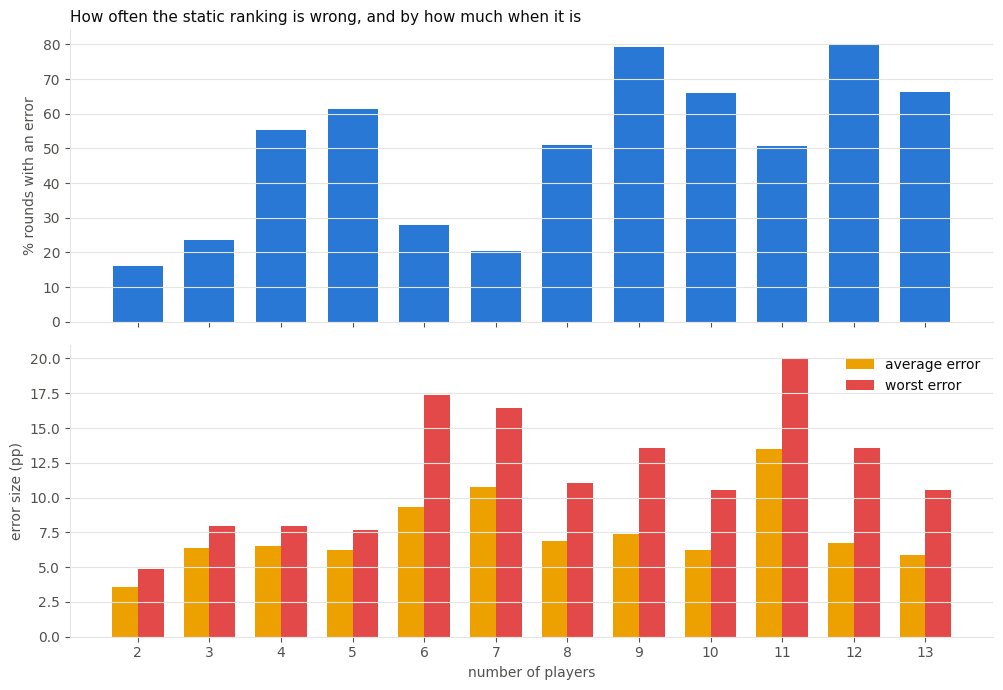

In [12]:
fig, axes = plt.subplots(2, 1, figsize=(10, 7), sharex=True)
axes[0].bar(df_cost["players"], df_cost["% rounds with an error"], color="#2a78d6", width=0.7)
axes[0].set_ylabel("% rounds with an error")
axes[0].set_title("How often the static ranking is wrong, and by how much when it is", loc="left", color=INK, fontsize=11)
axes[0].grid(axis="y", color=GRID, lw=0.8)

axes[1].bar(df_cost["players"] - 0.18, df_cost["avg. error when present (pp)"], width=0.36, color="#eda100", label="average error")
axes[1].bar(df_cost["players"] + 0.18, df_cost["worst error (pp)"], width=0.36, color="#e34948", label="worst error")
axes[1].set_ylabel("error size (pp)")
axes[1].set_xlabel("number of players")
axes[1].set_xticks(list(df_cost["players"]))
axes[1].grid(axis="y", color=GRID, lw=0.8)
axes[1].legend(frameon=False)
plt.tight_layout()
plt.show()

### Which specific category pairs are behind the worst error (2-7 players - priority group)

In [13]:
def worst_n_breakdown(ranking, lowest_rank, players, starting_cards, elimination_limit, epsilon_pp=EPSILON):
    dist = pool_size_distribution(players, starting_cards, elimination_limit)
    worst_n, worst_mass = None, -1.0
    for n in dist.by_pool_size:
        p = {c: probability(c, lowest_rank, n) for c in CATEGORIES}
        im = float(inversion_mass(ranking, p, epsilon_pp)) * 100
        if im > worst_mass:
            worst_mass, worst_n = im, n
    p = {c: probability(c, lowest_rank, worst_n) for c in CATEGORIES}
    pairs = []
    eps = epsilon_pp / 100
    for i, low in enumerate(ranking):
        for high in ranking[i + 1:]:
            diff = p[high] - p[low]
            if diff > eps:
                pairs.append((low, high, float(diff) * 100, float(p[low]) * 100, float(p[high]) * 100))
    return worst_n, worst_mass, pairs

rows = []
for players in range(2, 8):
    L = DECK_TABLE[players]
    start, limit = default_start(players), default_limit(players)
    ranking, _ = static_ranking(L, players, start, limit, epsilon_pp=EPSILON)
    n, mass, pairs = worst_n_breakdown(ranking, L, players, start, limit)
    pair_text = "; ".join(
        f"{LABELS[low]} {p_low:.1f}% vs {LABELS[high]} {p_high:.1f}% (difference {diff:.1f}pp)"
        for low, high, diff, p_low, p_high in pairs
    )
    rows.append({"players": players, "worst N": n, "total mass at this N (pp)": round(mass, 2), "inverted pairs": pair_text})
pd.DataFrame(rows).style.hide(axis="index")

players,worst N,total mass at this N (pp),inverted pairs
2,10,4.840000,flush 2.8% vs full house 7.6% (difference 4.8pp)
3,13,7.990000,pair 76.7% vs straight 84.7% (difference 8.0pp)
4,13,7.990000,pair 76.7% vs straight 84.7% (difference 8.0pp)
5,16,7.680000,pair 80.4% vs straight 88.1% (difference 7.7pp)
6,8,17.400000,straight 10.8% vs pair 25.4% (difference 14.6pp); flush 1.2% vs three of a kind 3.9% (difference 2.8pp)
7,9,16.410000,straight 11.4% vs pair 25.5% (difference 14.1pp); flush 2.6% vs two pair 4.9% (difference 2.3pp)


**Conclusion:** for 2-5 players a single pair (usually pair/straight) accounts for the entire error. For **6 and 7 players a second pair shows up at the same time** (straight/pair as the main problem, plus a smaller extra error from flush/three-of-a-kind or two-pair/flush) - which is why their combined totals are higher (17.4 pp and 14.5 pp) in the section-5c chart above. This is consistent with section 4: 6 and 7 players are among the player counts where pair/straight is unstable with respect to epsilon.

**How to read this:** the pattern is now more spread out than on the old deck - there's no single clearly "worst" group. **6, 7 and 11 players** have the largest single errors (14-20pp), and **9 and 12 players** have the highest share of affected rounds (79-80%), though a moderate average error size. This reflects what we saw in sections 2 and 4: it's now **5 players** that formally fails the 10% criterion (7 players passes once the starting-cards fix is applied - see section 2), and 4-7 players have an unstable pair/straight order - so these player counts are the priority to consider for staging (section 5d), not based on this one chart alone.

## 5d. Is it worth complicating the ranking? Data for a decision (not a recommendation)

As before: a staged ranking (one per game phase) as a pure information analysis, now on the corrected decks.

In [14]:
rows = []
staged_details = {}
for players in range(2, 14):
    L = DECK_TABLE[players]
    start, limit = default_start(players), default_limit(players)
    result = staged_ranking(L, players, start, limit, epsilon_pp=EPSILON)
    staged_details[players] = result
    changes_dyn = expected_ranking_changes(L, players, start, limit, epsilon_pp=EPSILON, hysteresis=True)
    reduction = (1 - float(result.staged_mass) / float(result.single_static_mass)) * 100 if result.single_static_mass > 0 else 0.0
    rows.append({
        "players": players, "m static (pp)": float(result.single_static_mass) * 100,
        "m staged (pp)": float(result.staged_mass) * 100, "error reduction": reduction,
        "switches/game (staged)": result.switches, "changes/game (full dynamic)": float(changes_dyn),
    })
df_staged = pd.DataFrame(rows)
df_staged.style.format({
    "m static (pp)": "{:.2f}", "m staged (pp)": "{:.2f}", "error reduction": "{:.0f}%",
    "changes/game (full dynamic)": "{:.1f}",
}).hide(axis="index")

players,m static (pp),m staged (pp),error reduction,switches/game (staged),changes/game (full dynamic)
2,0.57,0.57,0%,0,1.6
3,1.50,1.50,0%,0,2.6
4,3.60,1.24,66%,1,3.3
5,3.82,1.03,73%,1,3.4
6,2.59,0.63,76%,1,4.0
7,2.21,0.38,83%,1,3.6
8,3.49,2.16,38%,2,7.1
9,5.85,3.63,38%,3,7.3
10,4.12,2.26,45%,3,6.1
11,6.84,3.43,50%,2,6.1


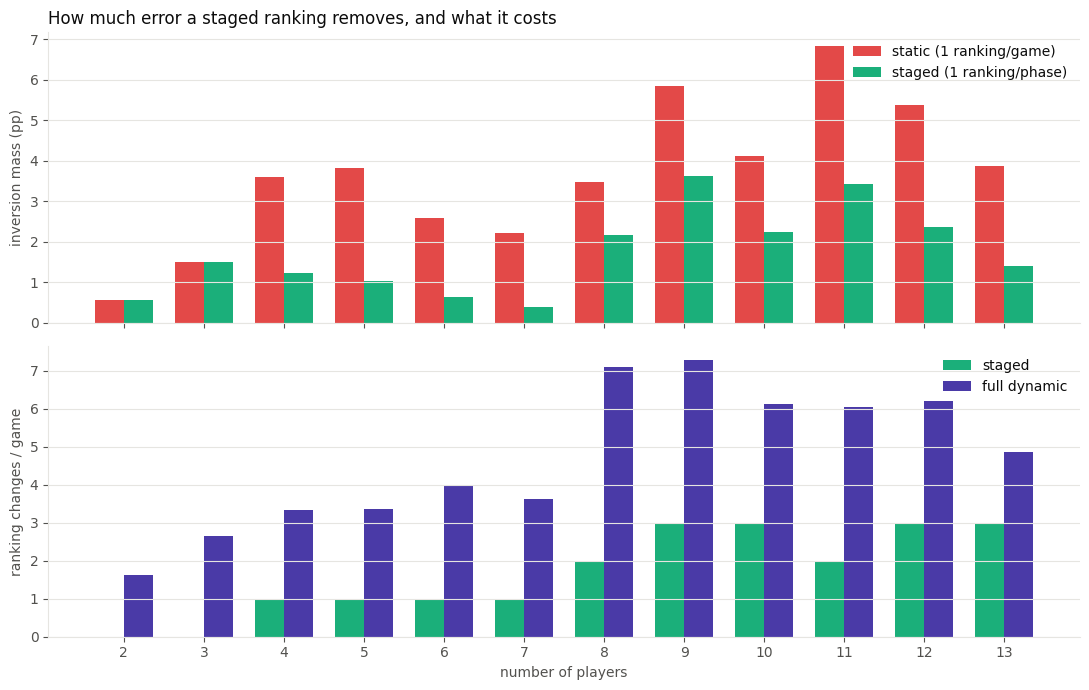

In [15]:
fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True)
axes[0].bar(df_staged["players"] - 0.18, df_staged["m static (pp)"], width=0.36, color="#e34948", label="static (1 ranking/game)")
axes[0].bar(df_staged["players"] + 0.18, df_staged["m staged (pp)"], width=0.36, color="#1baf7a", label="staged (1 ranking/phase)")
axes[0].set_ylabel("inversion mass (pp)")
axes[0].set_title("How much error a staged ranking removes, and what it costs", loc="left", color=INK, fontsize=12)
axes[0].grid(axis="y", color=GRID, lw=0.8)
axes[0].legend(frameon=False)

axes[1].bar(df_staged["players"] - 0.18, df_staged["switches/game (staged)"], width=0.36, color="#1baf7a", label="staged")
axes[1].bar(df_staged["players"] + 0.18, df_staged["changes/game (full dynamic)"], width=0.36, color="#4a3aa7", label="full dynamic")
axes[1].set_ylabel("ranking changes / game")
axes[1].set_xlabel("number of players")
axes[1].set_xticks(list(df_staged["players"]))
axes[1].grid(axis="y", color=GRID, lw=0.8)
axes[1].legend(frameon=False)
plt.tight_layout()
plt.show()

**Conclusion (updated):** on the corrected decks, staging still gives a real benefit for many player counts, but the picture of "who needs staging most" has changed - it's now mainly **4-7 players** (previously 6-13). This is still data for your decision, not a recommendation - see the summary in section 7.

## 6. Correctness test: a hand-worked case

We check `rank_categories` on a synthetic example: two categories differing by 0.1 pp (below epsilon=2pp) must stay in the baseline order.

In [16]:
p_example = {c: Fraction(1, 100) for c in CATEGORIES}
p_example["PAIR"] = Fraction(50, 1000)
p_example["STRAIGHT"] = Fraction(51, 1000)
ranking = rank_categories(p_example, epsilon_pp=EPSILON, base_order=CURRENT_ORDER)
print("pair stays before straight even though straight is strictly more frequent:", ranking.index("PAIR") < ranking.index("STRAIGHT"))

pair stays before straight even though straight is strictly more frequent: True


## 7. Conclusions (version 2, after recomputing the deck and starting cards)

**What is established:**

1. **The current ordering is wrong** for practically every player count (the current ranking's inversion mass ranges from about 10 to 120 pp).
2. **The static ranking is good enough (<=10%) for every player count but one:**
   - **4 players: a borderline case** (9.99%).
   - **5 players: NOT good enough** (14.40%) - the only such case once the starting-cards fix is applied. No choice of starting-card count fixes this (checked in notebook 4) - accepted as-is, the error is mild in practice (see notebook 4's starting-cards section).
   - **7 players: good enough** (4.74%) - but only thanks to raising the starting-cards threshold (2 starting cards instead of 1). Without that fix it wouldn't be good enough either, at 13.28%.
   - The rest (2, 3, 6, 8-13 players): good enough with margin.
3. **For 5 players, the natural next step would be considering dynamic.** We checked the cost: 3.4 ranking changes per game (section 5) - still substantial. **A staged ranking is a better trade-off** (section 5d): for 5 players, 73% error reduction for 1 switch per game. This is data for the decision that was ultimately made: a plain static ranking, with no staging, for every player count (see this repo's README for the final call).
4. **Recommended ordering changes, stable under sensitivity analysis:**
   - flush before pair - for 9-13 players,
   - pair before straight and flush - for 8 players.
5. **Unstable, not recommended changes:** pair/straight for **4, 5, 6, 7 players** - a difference on the order of +-1.3 to +-2 pp, within the noise. They stay in today's order.

**Change relative to the engine's original deck:** the "borderline" problem moved from the flush/pair pair (6-7 players, engine's deck) to the pair/straight pair (4-7 players, deck chosen in notebook 4) - and additionally revealed that for 5 and 7 players the static ranking **formally failed** its own 10% criterion under today's starting-card settings. For 7 players this was fixable; for 5, it wasn't.

**Summary of the decisions to make (all the data is ready, the choice is yours):**

| Players | Is static good enough? | Recommendation |
|---|---|---|
| 2, 3, 6, 8-13 | yes, with margin | static, unchanged |
| 4 | borderline (9.99%) | static, but worth watching if parameters change |
| 7 | yes, after the starting-cards fix (4.74%) | static + 2 starting cards |
| **5** | **no** (14.4%) | static, a knowingly accepted error - staging would give a 73% reduction for 1 switch, but was ultimately rejected in favor of simplicity |

**Uncertainty:** every number is an exact value from formulas (notebook 1) and a Markov chain (notebook 2). The epsilon, 10%, 5% thresholds are design decisions fixed before any results existed, not results of computation.